In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/IE7615 - Deep Learning/02_project01_milestone1")

IDS = ["7007", "2970", "2336", "7", "4428"]

for identity in IDS:
    files = list((DATA_DIR / identity).glob("*"))
    print(identity, ":", len(files), "images")

7007 : 24 images
2970 : 25 images
2336 : 25 images
7 : 24 images
4428 : 24 images


In [4]:
OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/IE7615 - Deep Learning/03_project01_milestone2")

SYNTHETIC_DIR = OUTPUT_DIR / "synthetic_images"

SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)

print("Synthetic images will be saved to:", SYNTHETIC_DIR)

Synthetic images will be saved to: /content/drive/MyDrive/Colab Notebooks/IE7615 - Deep Learning/03_project01_milestone2/synthetic_images


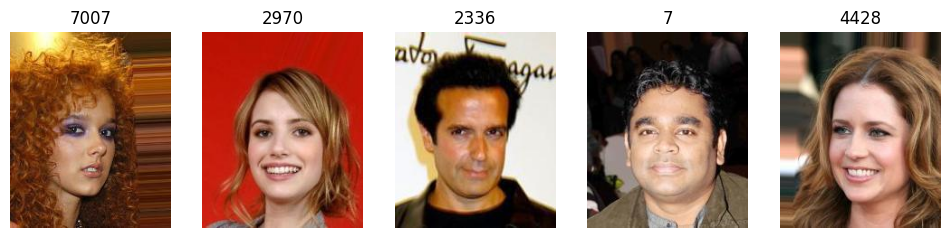

In [5]:
plt.figure(figsize=(12, 3))

for i, identity in enumerate(IDS):
    image_files = list((DATA_DIR / identity).glob("*"))
    img = Image.open(image_files[0])

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(identity)
    plt.axis("off")

plt.show()

In [6]:
def make_background():
    background = Image.new("RGB", (800, 600), (225, 220, 210))

    pixels = background.load()

    for y in range(450, 600):
        for x in range(800):
            pixels[x, y] = (185, 175, 165)

    return background

In [7]:
def create_group_image(image_number):
    group_image = make_background()

    # randomly choose 2 or 3 different celebrities
    selected_ids = random.sample(IDS, random.randint(2, 3))

    placements = []

    for i, identity in enumerate(selected_ids):

        # choose a random image for this celebrity
        image_files = (
    list((DATA_DIR / identity).glob("*.jpg")) +
    list((DATA_DIR / identity).glob("*.jpeg")) +
    list((DATA_DIR / identity).glob("*.png"))
)
        img = Image.open(random.choice(image_files)).convert("RGB")

        # vary the size
        width = random.randint(170, 220)
        height = random.randint(220, 280)
        img = img.resize((width, height))

        # vary the brightness
        brightness = random.uniform(0.8, 1.2)
        img = ImageEnhance.Brightness(img).enhance(brightness)

        # give each person a different section of the image
        section_width = 800 // len(selected_ids)
        x = i * section_width + random.randint(10, 40)
        y = random.randint(100, 280)

        group_image.paste(img, (x, y))

        placements.append({
            "identity": identity,
            "x": x,
            "y": y,
            "width": width,
            "height": height
        })

    # save the finished image
    file_name = f"synthetic_{image_number:03d}.jpg"
    group_image.save(SYNTHETIC_DIR / file_name)

    return group_image, placements

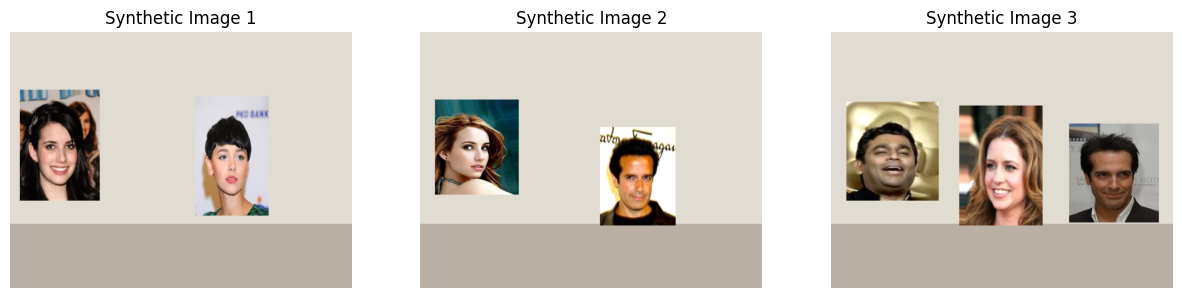

In [8]:
plt.figure(figsize=(15, 5))

for i in range(3):
    img, placements = create_group_image(i)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Synthetic Image {i + 1}")

plt.show()

In [9]:
import pandas as pd

all_placements = []

for i in range(50):
    img, placements = create_group_image(i)

    for person in placements:
        all_placements.append({
            "image": f"synthetic_{i:03d}.jpg",
            "identity": person["identity"],
            "x": person["x"],
            "y": person["y"],
            "width": person["width"],
            "height": person["height"]
        })

placement_df = pd.DataFrame(all_placements)

placement_df.to_csv(
    OUTPUT_DIR / "synthetic_placements.csv",
    index=False
)

print("Synthetic images created:", 50)
print("Total celebrity placements:", len(placement_df))

placement_df.head(10)

Synthetic images created: 50
Total celebrity placements: 126


,image,identity,x,y,width,height
0,synthetic_000.jpg,2336,39,226,193,261
1,synthetic_000.jpg,7007,288,215,182,263
2,synthetic_000.jpg,2970,550,178,179,276
3,synthetic_001.jpg,4428,12,154,207,251
4,synthetic_001.jpg,2336,293,152,183,267
5,synthetic_001.jpg,2970,551,120,208,257
6,synthetic_002.jpg,2336,37,239,218,262
7,synthetic_002.jpg,7007,437,154,216,250
8,synthetic_003.jpg,4428,13,165,207,222
9,synthetic_003.jpg,7007,287,245,184,230


In [10]:
saved_images = list(SYNTHETIC_DIR.glob("*.jpg"))

print("Number of saved images:", len(saved_images))

Number of saved images: 50


### Synthetic Multi-Celebrity Image Construction

Using the five celebrity identities selected in Milestone 1, 50 synthetic multi-celebrity images were created. Each synthetic image contains 2–3 randomly selected identities placed on a shared 800 × 600 background.

To add variation across the dataset, a random source image was selected for each identity and the image size, position, and brightness were varied. This prevents every synthetic image from using the same layout or appearance.

For each synthetic image, the identity, position, width, and height of each placed celebrity were also recorded in `synthetic_placements.csv`. This information can be used to create the bounding box annotations required for the YOLO detection dataset.

In [11]:
identity_counts = placement_df["identity"].value_counts().sort_index()

print("Number of appearances for each identity:")
print(identity_counts)

Number of appearances for each identity:
identity
2336    31
2970    25
4428    24
7       25
7007    21
Name: count, dtype: int64


## Step 2 — YOLO-format Face Annotations

This section adds face annotations to the synthetic images already created above.
**To annotate the existing dataset, run only the cells in Step 2.** Running the
construction cells again creates new random images and overwrites their placements.

The placement CSV describes each pasted **photograph**, including hair, clothing,
and background. The assignment requires tight boxes around **faces**. We therefore
run a pretrained YuNet face detector inside each known photograph, then use the
CSV identity to assign its class. The detector locates faces; it does not identify
celebrities or train the final YOLO model.

### 2.1 Mount Google Drive and load the existing dataset

Colab runs on a remote Linux machine. Its working directory is usually `/content`,
not the folder containing the notebook. Use the explicit Google Drive path below;
the Windows `C:` drive is not mounted here. The paths match the existing notebook.


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from google.colab import drive

if not Path('/content/drive/MyDrive').is_dir():
    drive.mount('/content/drive')

OUTPUT_DIR = Path('/content/drive/MyDrive/Colab Notebooks/IE7615 - Deep Learning/03_project01_milestone2')
SYNTHETIC_DIR = OUTPUT_DIR / 'synthetic_images'
PLACEMENTS_FILE = OUTPUT_DIR / 'synthetic_placements.csv'
LABELS_DIR = OUTPUT_DIR / 'yolo_labels'
EXPECTED_IMAGE_COUNT = 50

print('Colab working directory:', Path.cwd())
print('Dataset directory:', OUTPUT_DIR)
print('Directory contents:', ', '.join(p.name for p in sorted(OUTPUT_DIR.iterdir())))

placement_df = pd.read_csv(PLACEMENTS_FILE, dtype={'image': str, 'identity': str})
image_paths = sorted(SYNTHETIC_DIR.glob('synthetic_*.jpg'))

# Keep this mapping unchanged during augmentation, splitting, and training.
CLASS_NAMES = ['7007', '2970', '2336', '7', '4428']
CLASS_ID = {identity: index for index, identity in enumerate(CLASS_NAMES)}
class_mapping = pd.DataFrame({'class_id': range(len(CLASS_NAMES)), 'identity': CLASS_NAMES})

assert len(image_paths) == EXPECTED_IMAGE_COUNT, f'Expected 50 images; found {len(image_paths)}.'
assert set(p.name for p in image_paths) == set(placement_df['image']), 'Image filenames and CSV entries do not match.'
assert set(placement_df['identity']).issubset(CLASS_ID), 'The CSV contains an unknown identity.'
assert not placement_df.duplicated(['image', 'identity']).any(), 'An identity appears twice in one image.'

print(f'Images found: {len(image_paths)}; expected face annotations: {len(placement_df)}')
display(class_mapping)


Colab working directory: /content
Dataset directory: /content/drive/MyDrive/Colab Notebooks/IE7615 - Deep Learning/03_project01_milestone2
Directory contents: synthetic_images, synthetic_placements.csv
Images found: 50; expected face annotations: 126


,class_id,identity
0,0,7007
1,1,2970
2,2,2336
3,3,7
4,4,4428


### 2.2 Load the face detector

YuNet runs on the CPU for this small dataset. OpenCV is normally available in
Colab; the cell installs it only if missing. The approximately 227 KB pretrained
model is downloaded to the Colab runtime. We use a confidence threshold of `0.70`
and non-maximum suppression of `0.30`.

Reference: [OpenCV face detection tutorial](https://docs.opencv.org/4.12.0/d0/dd4/tutorial_dnn_face.html).


In [13]:
import importlib.util
import subprocess
import sys
import urllib.request

if importlib.util.find_spec('cv2') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'opencv-python-headless==4.12.0.88'])

import cv2

assert tuple(map(int, cv2.__version__.split('.')[:2])) >= (4, 8), 'YuNet requires OpenCV 4.8 or newer.'
MODEL_PATH = Path('/content/face_detection_yunet_2023mar.onnx')
MODEL_URL = 'https://media.githubusercontent.com/media/opencv/opencv_zoo/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx'

if not MODEL_PATH.exists():
    with urllib.request.urlopen(MODEL_URL, timeout=30) as response:
        MODEL_PATH.write_bytes(response.read())

assert MODEL_PATH.stat().st_size > 1000, 'The downloaded file is not the YuNet model.'
detector = cv2.FaceDetectorYN.create(str(MODEL_PATH), '', (320, 320), 0.70, 0.30, 5000)
print('Face detector ready. OpenCV version:', cv2.__version__)


Face detector ready. OpenCV version: 4.14.0


### 2.3 Detect faces and write YOLO labels

Each label file uses the same stem as its image, for example
`synthetic_000.jpg` → `yolo_labels/synthetic_000.txt`. Each face has one line:

```text
class_id x_center y_center width height
```

The four coordinates are normalized to the **entire synthetic image**, not to
the individual pasted photograph:

- `x_center = (x_min + x_max) / (2 × image_width)`
- `y_center = (y_min + y_max) / (2 × image_height)`
- `width = (x_max - x_min) / image_width`
- `height = (y_max - y_min) / image_height`

There must be exactly one detected face per CSV placement. If a crop has zero or
multiple detections, this cell displays it with global pixel coordinates and
stops **before exporting any labels**. In that case, add a corrected face box to
`MANUAL_BOXES`, using `(x_min, y_min, x_max, y_max)` in the full image, and rerun
this cell. For example, the dictionary syntax is
`{('synthetic_012.jpg', '2336'): (x_min, y_min, x_max, y_max)}`; use your actual
coordinates. Leave it empty when all detections succeed.

Reference: [Ultralytics YOLO label format](https://docs.ultralytics.com/datasets/detect/).


In [16]:
annotation_complete = False
MANUAL_BOXES = { ("synthetic_018.jpg", "2970"): (50, 220, 185, 370)}
face_records = []
review_items = []

for image_path in image_paths:
    image_bgr = cv2.imread(str(image_path))
    assert image_bgr is not None, f'Could not read {image_path.name}.'
    image_height, image_width = image_bgr.shape[:2]
    placements = placement_df[placement_df['image'] == image_path.name]

    for row in placements.itertuples(index=False):
        x, y, w, h = int(row.x), int(row.y), int(row.width), int(row.height)
        assert 0 <= x < x + w <= image_width and 0 <= y < y + h <= image_height, f'Invalid placement in {image_path.name}.'
        crop = image_bgr[y:y + h, x:x + w].copy()
        key = (image_path.name, row.identity)

        if key in MANUAL_BOXES:
            x_min, y_min, x_max, y_max = map(float, MANUAL_BOXES[key])
            score, method = np.nan, 'manual'
        else:
            detector.setInputSize((w, h))
            _, faces = detector.detect(crop)
            if faces is None or len(faces) != 1:
                review_items.append({'image': image_path.name, 'identity': row.identity,
                                     'faces_found': 0 if faces is None else len(faces),
                                     'crop': crop, 'x': x, 'y': y, 'width': w, 'height': h})
                continue

            face_x, face_y, face_w, face_h = map(float, faces[0, :4])
            # Convert crop-relative coordinates to the full image and clip to the crop.
            x_min, y_min = x + max(0.0, face_x), y + max(0.0, face_y)
            x_max, y_max = x + min(float(w), face_x + face_w), y + min(float(h), face_y + face_h)
            score, method = float(faces[0, -1]), 'yunet'

        assert np.isfinite([x_min, y_min, x_max, y_max]).all(), 'The face box contains non-finite coordinates.'
        assert x <= x_min < x_max <= x + w and y <= y_min < y_max <= y + h, f'Invalid face box for {key}.'

        face_records.append({
            'image': image_path.name, 'identity': row.identity, 'class_id': CLASS_ID[row.identity],
            'x_min': x_min, 'y_min': y_min, 'x_max': x_max, 'y_max': y_max,
            'x_center': (x_min + x_max) / (2 * image_width),
            'y_center': (y_min + y_max) / (2 * image_height),
            'width': (x_max - x_min) / image_width, 'height': (y_max - y_min) / image_height,
            'confidence': score, 'method': method
        })

if review_items:
    display(pd.DataFrame([{k: r[k] for k in ['image', 'identity', 'faces_found']} for r in review_items]))
    for item in review_items:
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(cv2.cvtColor(item['crop'], cv2.COLOR_BGR2RGB),
                  extent=(item['x'], item['x'] + item['width'], item['y'] + item['height'], item['y']))
        ax.set_title(f"{item['image']} | identity {item['identity']}")
        ax.set_xlabel('Full-image x pixels')
        ax.set_ylabel('Full-image y pixels')
        plt.show()
        plt.close(fig)
    raise RuntimeError('Review the listed crops, add their face boxes to MANUAL_BOXES, and rerun this cell. No labels were exported in this run.')

face_annotations = pd.DataFrame(face_records)
assert len(face_annotations) == len(placement_df), 'A face annotation is missing.'
assert face_annotations[['x_center', 'y_center', 'width', 'height']].gt(0).all().all()
assert face_annotations[['x_center', 'y_center', 'width', 'height']].le(1).all().all()

LABELS_DIR.mkdir(parents=True, exist_ok=True)
for image_name, boxes in face_annotations.groupby('image', sort=True):
    lines = [f'{int(r.class_id)} {r.x_center:.6f} {r.y_center:.6f} {r.width:.6f} {r.height:.6f}'
             for r in boxes.itertuples(index=False)]
    (LABELS_DIR / f'{Path(image_name).stem}.txt').write_text('\n'.join(lines) + '\n', encoding='utf-8')

class_mapping.to_csv(OUTPUT_DIR / 'class_mapping.csv', index=False)
(OUTPUT_DIR / 'classes.txt').write_text('\n'.join(CLASS_NAMES) + '\n', encoding='utf-8')
face_annotations.to_csv(OUTPUT_DIR / 'face_annotations.csv', index=False)
annotation_complete = True

print(f'YOLO label files written: {len(image_paths)}')
print(f'Face annotations written: {len(face_annotations)}')
print('Labels directory:', LABELS_DIR)
display(face_annotations.groupby(['class_id', 'identity']).size().reset_index(name='face_count'))


YOLO label files written: 50
Face annotations written: 126
Labels directory: /content/drive/MyDrive/Colab Notebooks/IE7615 - Deep Learning/03_project01_milestone2/yolo_labels


,class_id,identity,face_count
0,0,7007,21
1,1,2970,25
2,2,2336,31
3,3,7,25
4,4,4428,24


### 2.4 Verify the exported label files and display five examples

This cell checks **every exported `.txt` file** against the CSV face count, then
draws five examples by reading the normalized coordinates back from those files.
Verify that the boxes follow the faces rather than the borders of the pasted
photographs, and that each displayed identity agrees with its class mapping.


Validated all 50 label files.


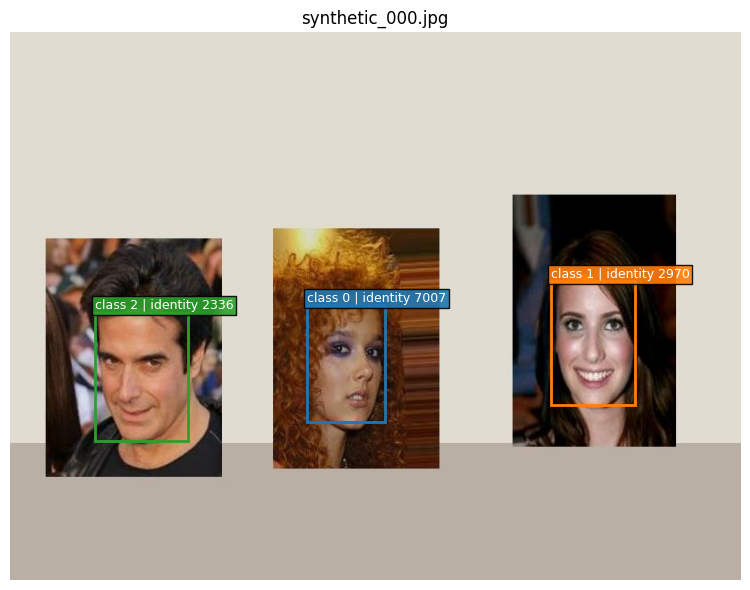

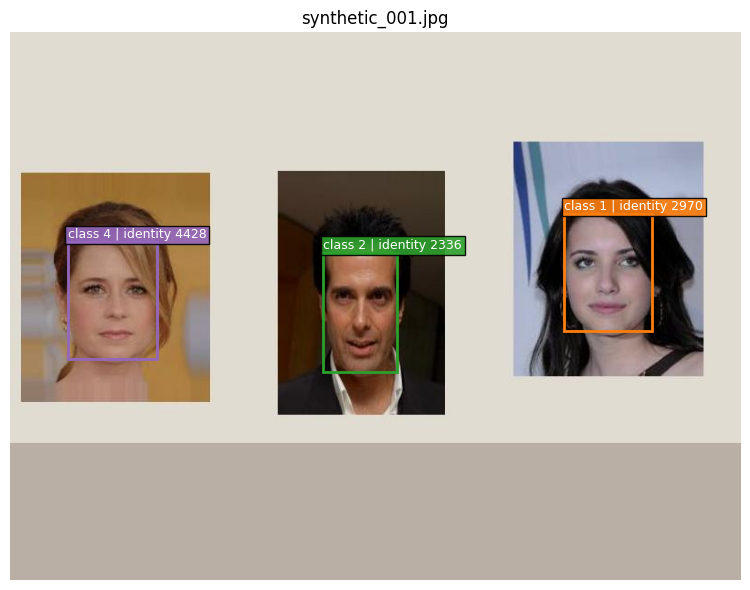

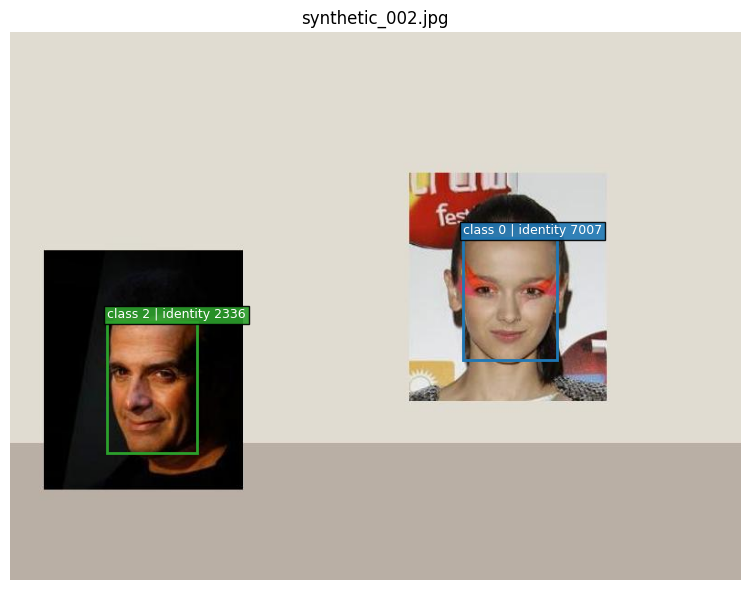

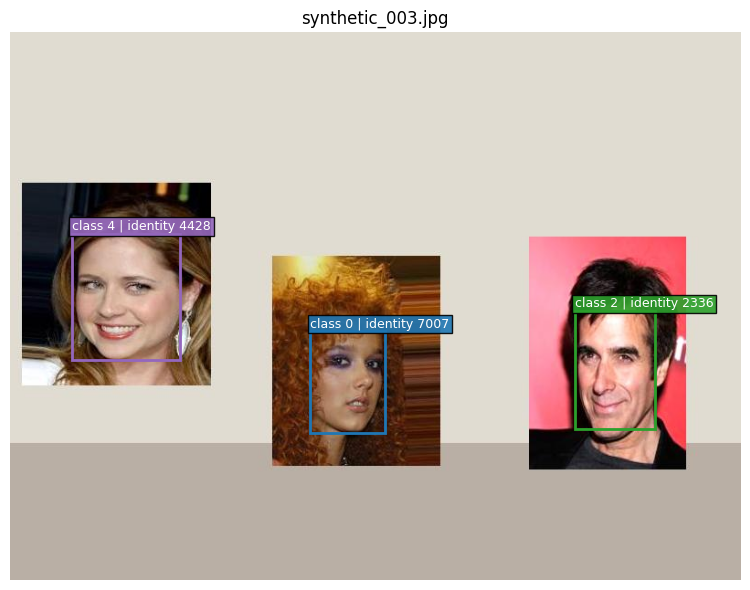

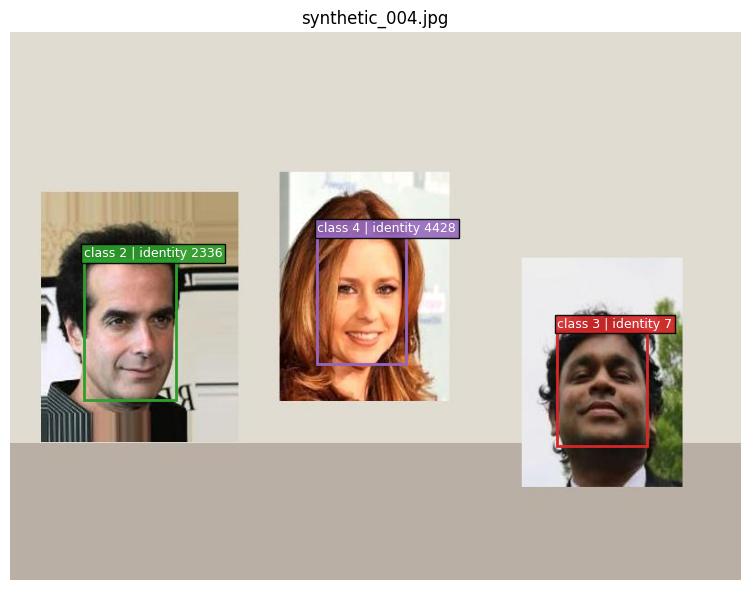

Example YOLO label — synthetic_000.txt:
2 0.179664 0.628193 0.127432 0.234121
0 0.459501 0.604346 0.107888 0.212921
1 0.797474 0.566467 0.115701 0.224846



In [17]:
from matplotlib.patches import Rectangle

assert annotation_complete, 'Complete the annotation cell successfully first.'
for image_path in image_paths:
    label_path = LABELS_DIR / f'{image_path.stem}.txt'
    lines = label_path.read_text(encoding='utf-8').splitlines()
    expected_classes = placement_df.loc[placement_df['image'] == image_path.name, 'identity'].map(CLASS_ID).tolist()
    assert len(lines) == len(expected_classes), f'Wrong face count in {label_path.name}.'
    exported_classes = []
    for line in lines:
        values = list(map(float, line.split()))
        assert len(values) == 5, f'Invalid YOLO row in {label_path.name}.'
        class_id, x_center, y_center, box_width, box_height = values
        assert class_id.is_integer() and 0 <= class_id < len(CLASS_NAMES)
        assert np.isfinite(values).all() and 0 < box_width <= 1 and 0 < box_height <= 1
        assert 0 <= x_center - box_width / 2 and x_center + box_width / 2 <= 1 + 1e-6
        assert 0 <= y_center - box_height / 2 and y_center + box_height / 2 <= 1 + 1e-6
        exported_classes.append(int(class_id))
    assert sorted(exported_classes) == sorted(expected_classes), f'Class mismatch in {label_path.name}.'

print(f'Validated all {len(image_paths)} label files.')
colors = plt.get_cmap('tab10')
for image_path in image_paths[:5]:
    with Image.open(image_path) as img:
        image_width, image_height = img.size
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(img)

    for line in (LABELS_DIR / f'{image_path.stem}.txt').read_text().splitlines():
        class_id, x_center, y_center, box_width, box_height = map(float, line.split())
        class_id = int(class_id)
        x_min = (x_center - box_width / 2) * image_width
        y_min = (y_center - box_height / 2) * image_height
        width, height = box_width * image_width, box_height * image_height
        color = colors(class_id)
        ax.add_patch(Rectangle((x_min, y_min), width, height, fill=False, edgecolor=color, linewidth=2))
        ax.text(x_min, y_min - 4, f'class {class_id} | identity {CLASS_NAMES[class_id]}',
                color='white', fontsize=9, bbox={'facecolor': color, 'alpha': 0.9, 'pad': 2})

    ax.set_title(image_path.name)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

example_label = LABELS_DIR / f'{image_paths[0].stem}.txt'
print(f'Example YOLO label — {example_label.name}:')
print(example_label.read_text(encoding='utf-8'))


### Step 2 outputs

- `yolo_labels/`: one YOLO `.txt` file per synthetic image, with one row per face.
- `classes.txt` and `class_mapping.csv`: the fixed five-class identity mapping.
- `face_annotations.csv`: face boxes in full-image pixels, normalized YOLO
  coordinates, detector confidence, and whether a box was detected or corrected.

The original photographs and placement CSV remain the inputs to this section.
For the next team steps, pass the synthetic images, their matching labels, and
the class mapping together. Augmentation must transform face boxes with the
images. The train/validation/test folder layout and `data.yaml` belong to the
later dataset-splitting step.
